### PuTTY log 2023.07.02 10:30:09 balkon u stanu
Sunčano s povremenom naoblakom, bez dimljaka, 60%-50% humidity, 29.84 inHg

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import ascii

38.28 [30.9]


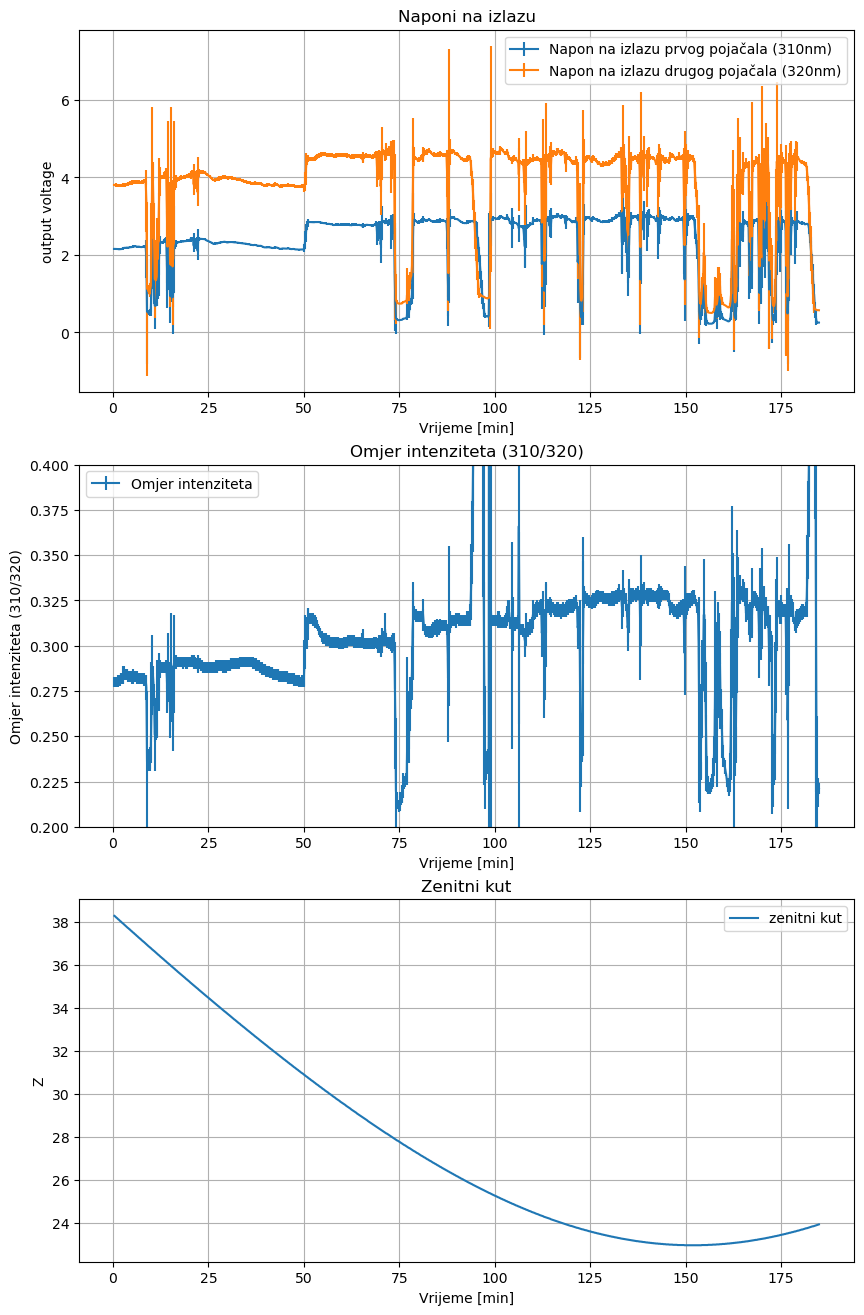

(array([614], dtype=int64),)

In [2]:
i, meanV1, meanV2, meanRatio, stdV1, stdV2, stdRatio, el = np.loadtxt('ozone_0207.csv', delimiter=",",
                                                                  dtype = 'float', unpack=True,skiprows=5)
el = el - 0.2

print(90-el[0],90-el[np.where(i==2999)])

window = int(len(meanRatio))
avgRatio = scipy.signal.savgol_filter(meanRatio, window,2)
lnRatio = -100*np.log10(np.e)*np.log(avgRatio)
fig, ax = plt.subplots(3,1,figsize=(10,16))
ax[0].errorbar(i/60, meanV1, stdV1, linestyle='-',label='Napon na izlazu prvog pojačala (310nm)')
ax[0].errorbar(i/60, meanV2, stdV2, linestyle='-',label='Napon na izlazu drugog pojačala (320nm)')
ax[0].set(xlabel='Vrijeme [min]', ylabel='output voltage',title='Naponi na izlazu')
ax[0].grid()
ax[0].legend(loc='best')
ax[1].errorbar(i/60,meanRatio,stdRatio,label='Omjer intenziteta')
ax[1].set(xlabel='Vrijeme [min]', ylabel='Omjer intenziteta (310/320)',title='Omjer intenziteta (310/320)',
         ylim=(0.2,0.4))
ax[1].grid()
ax[1].legend(loc='best')
ax[2].plot(i/60, 90-el, linestyle='-', label='zenitni kut')
ax[2].set(xlabel='Vrijeme [min]', ylabel='Z',title='Zenitni kut')
ax[2].grid()
ax[2].legend(loc='best')
plt.show()
plt.close(fig)
np.where(el==65.00)

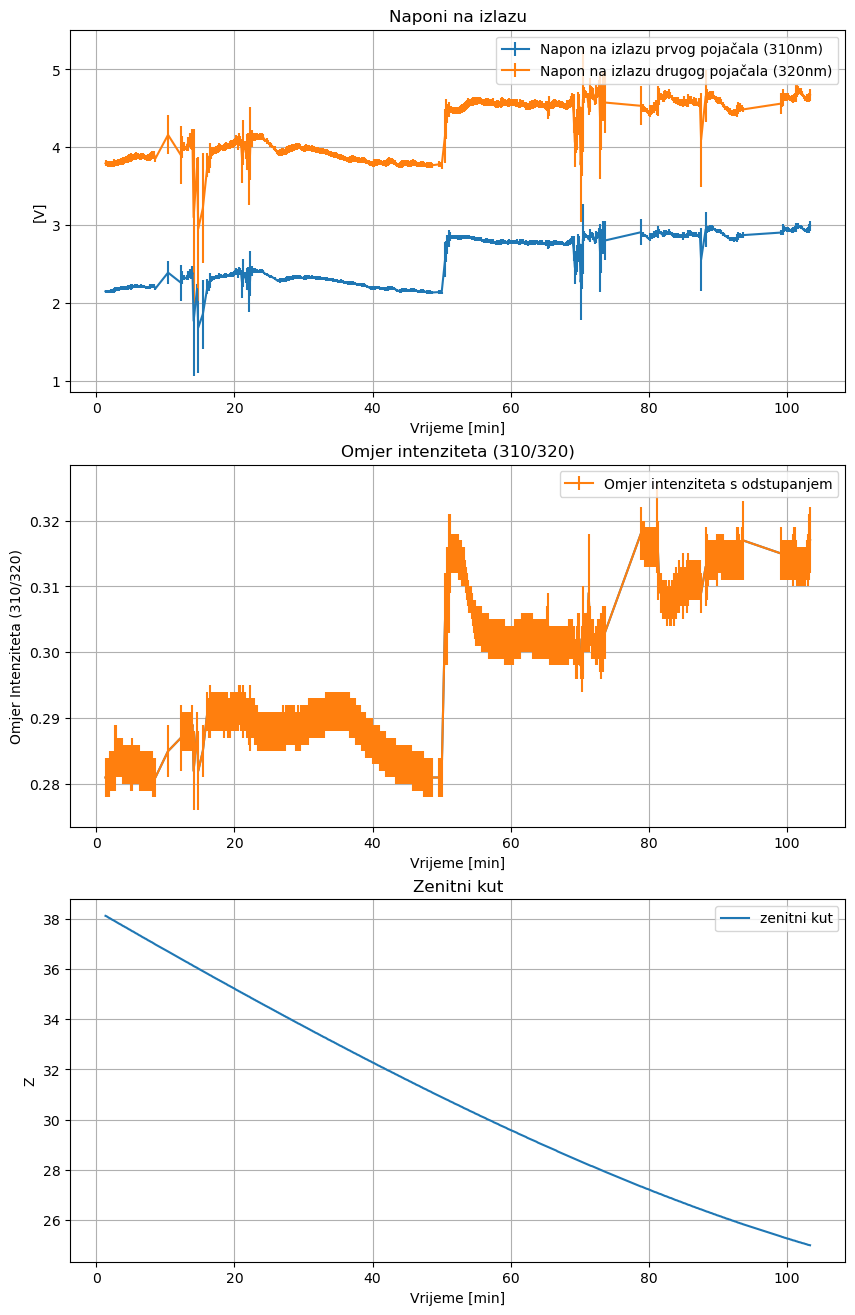

In [3]:
i=i[0:615] #422
el=el[0:615]
meanRatio=meanRatio[0:615]
stdRatio=stdRatio[0:615]
meanV1=meanV1[0:615]
meanV2=meanV2[0:615]
stdV1=stdV1[0:615]
stdV2=stdV2[0:615]

I = np.logical_and(meanRatio>0.28,stdRatio<0.01)
i = i[np.where(I==True)]
meanV1=meanV1[np.where(I==True)]
meanV2=meanV2[np.where(I==True)]
stdV1=stdV1[np.where(I==True)]
stdV2=stdV2[np.where(I==True)]
meanRatio=meanRatio[np.where(I==True)]
stdRatio=stdRatio[np.where(I==True)]
el=el[np.where(I==True)]

window = int(len(meanRatio))
#avgRatio = scipy.signal.savgol_filter(meanRatio, window,2)
#lnRatio = -100*np.log10(np.e)*np.log(avgRatio)
fig, ax = plt.subplots(3,1,figsize=(10,16))
ax[0].errorbar(i/60, meanV1,stdV1, linestyle='-',label='Napon na izlazu prvog pojačala (310nm)')
ax[0].errorbar(i/60, meanV2,stdV2, linestyle='-',label='Napon na izlazu drugog pojačala (320nm)')
ax[0].set(xlabel='Vrijeme [min]', ylabel='[V]',title='Naponi na izlazu')
ax[0].grid()
ax[0].legend(loc='best')
ax[1].plot(i/60, meanRatio, linestyle='-')
ax[1].errorbar(i/60,meanRatio,stdRatio,label='Omjer intenziteta s odstupanjem')
ax[1].set(xlabel='Vrijeme [min]', ylabel='Omjer Intenziteta (310/320)',title='Omjer intenziteta (310/320)')
ax[1].grid()
ax[1].legend(loc='best')
ax[2].plot(i/60, 90-el, linestyle='-', label='zenitni kut')
ax[2].set(xlabel='Vrijeme [min]', ylabel='Z',title='Zenitni kut')
ax[2].grid()
ax[2].legend(loc='best')
plt.show()
plt.close(fig)